# Tiền xử lý và chuẩn hóa bộ dataset UIT-OpenViIC

Notebook này thực hiện đọc dữ liệu, chuẩn hóa annotation, phân tích thống kê mô tả, kiểm tra chất lượng, kiểm tra tính toàn vẹn ảnh, làm sạch dữ liệu và xuất dữ liệu đầu ra phục vụ bước chuẩn bị trước khi finetune BLIP cho bài toán image captioning tiếng Việt.

In [18]:
from pathlib import Path
from collections import Counter
import json
import re
import unicodedata
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image, UnidentifiedImageError

pd.set_option('display.max_colwidth', 160)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')

project_dir = Path.cwd()
data_dir = project_dir / 'data'
images_dir = data_dir / 'images'
annotation_files = {
    'train': data_dir / 'uit-openviic-annotation-train.json',
    'dev': data_dir / 'uit-openviic-annotation-dev.json',
    'test': data_dir / 'uit-openviic-annotation-test.json'
}

print('Project directory:', project_dir)
print('Data directory:', data_dir)
for split_name, file_path in annotation_files.items():
    print(f'{split_name}:', file_path, '| exists =', file_path.exists())
print('Images directory exists =', images_dir.exists())

Project directory: c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode
Data directory: c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data
train: c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\uit-openviic-annotation-train.json | exists = True
dev: c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\uit-openviic-annotation-dev.json | exists = True
test: c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\uit-openviic-annotation-test.json | exists = True
Images directory exists = True


## Đọc dữ liệu

Phần này đọc ba file annotation, khám phá nhanh cấu trúc JSON thực tế và chuẩn bị hàm suy luận schema để đưa toàn bộ dữ liệu về một định dạng chung.

In [19]:
raw_annotations = {
    split_name: json.loads(file_path.read_text(encoding='utf-8'))
    for split_name, file_path in annotation_files.items()
}

def preview_json_structure(name, obj):
    lines = []
    lines.append(f'Split: {name}')
    lines.append(f'Top-level type: {type(obj).__name__}')
    if isinstance(obj, dict):
        lines.append(f'Top-level size: {len(obj)}')
        sample_keys = list(obj.keys())[:5]
        lines.append(f'Sample keys: {sample_keys}')
        if sample_keys:
            first_key = sample_keys[0]
            first_value = obj[first_key]
            lines.append(f'Sample value type: {type(first_value).__name__}')
            if isinstance(first_value, dict):
                lines.append(f'Sample nested keys: {list(first_value.keys())[:10]}')
                sample_nested = {k: first_value[k] for k in list(first_value.keys())[:3]}
                lines.append('Sample nested value:')
                lines.append(json.dumps(sample_nested, ensure_ascii=False, indent=2)[:1000])
            elif isinstance(first_value, list):
                lines.append(f'Sample list length: {len(first_value)}')
                if first_value:
                    lines.append(json.dumps(first_value[:3], ensure_ascii=False, indent=2)[:1000])
            else:
                lines.append(repr(first_value)[:1000])
    elif isinstance(obj, list):
        lines.append(f'Top-level size: {len(obj)}')
        if obj:
            lines.append(f'First item type: {type(obj[0]).__name__}')
            lines.append(json.dumps(obj[0], ensure_ascii=False, indent=2)[:1000])
    return '\n'.join(lines)

for split_name, annotation_obj in raw_annotations.items():
    display(Markdown('### ' + split_name.upper()))
    print(preview_json_structure(split_name, annotation_obj))
    print()


### TRAIN

Split: train
Top-level type: dict
Top-level size: 9088
Sample keys: ['00000000782.jpg', '00000000783.jpg', '00000000784.jpg', '00000000785.jpg', '00000000786.jpg']
Sample value type: dict
Sample nested keys: ['captions']
Sample nested value:
{
  "captions": [
    "một con phố vắng vẻ có một tán cây lớn che ngang",
    "có một cái cây xanh trên vỉa hè phía bên phải của con đường nhựa",
    "có một người đang chạy xe băng qua ngã tư đường",
    "một người đang đi xe máy qua góc ngã tư có cây xanh nằm ở góc đường và các tòa nhà dọc theo các con đường",
    "có một con đường đầy cây xanh và những dãy nhà"
  ]
}



### DEV

Split: dev
Top-level type: dict
Top-level size: 2011
Sample keys: ['00000000400.jpg', '00000000401.jpg', '00000000402.jpg', '00000000403.jpg', '00000000404.jpg']
Sample value type: dict
Sample nested keys: ['captions']
Sample nested value:
{
  "captions": [
    "một cô gái tóc dài màu đen đang ngồi trên chiếc ghế sofa màu hồng với một vài cây xương rồng xung quanh",
    "một cô gái người nước ngoài mặc váy đen đang ngồi trước một bức tường màu hồng",
    "một cô gái mặc đầm đen đang ngồi trên một chiếc ghế màu hồng",
    "một cô gái bận đầm đen đang xõa tóc và  ngồi trên băng ghế màu hồng có trồng xương rồng đằng sau",
    "có một cô gái đang ngồi sau lưng cô là màu hồng"
  ]
}



### TEST

Split: test
Top-level type: dict
Top-level size: 2001
Sample keys: ['00000006091.jpg', '00000006092.jpg', '00000006093.png', '00000006094.jpg', '00000006095.jpg']
Sample value type: dict
Sample nested keys: ['captions']
Sample nested value:
{
  "captions": [
    "một ngôi nhà màu vàng có các sợi dây leo màu xanh quấn xung quanh",
    "một ngôi nhà cũ lâu đời màu vàng bên trong có nhiều cây to lớn",
    "một ngôi nhà cổ cao tầng màu vàng phía trước có nhiều cây",
    "một ngôi nhà màu vàng có mái màu đỏ với nhiều cửa sổ màu xanh",
    "một tòa nhà màu vàng được xây ở giữa rừng cây xanh"
  ]
}



In [20]:
def looks_like_image_file(value):
    if not isinstance(value, str):
        return False
    return value.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))

def infer_split_name(raw_name):
    text = str(raw_name).lower()
    if 'train' in text:
        return 'train'
    if 'dev' in text or 'valid' in text or 'val' in text:
        return 'dev'
    if 'test' in text:
        return 'test'
    return str(raw_name)

def find_first_value(container, candidate_keys):
    if not isinstance(container, dict):
        return None
    lowered = {str(key).lower(): key for key in container.keys()}
    for candidate in candidate_keys:
        if candidate in lowered:
            return container[lowered[candidate]]
    return None

def extract_caption_list(value):
    if value is None:
        return []
    if isinstance(value, str):
        return [value]
    if isinstance(value, list):
        captions = []
        for item in value:
            if isinstance(item, str):
                captions.append(item)
            elif isinstance(item, dict):
                nested_caption = find_first_value(item, ['caption', 'text', 'sentence', 'raw', 'description'])
                if isinstance(nested_caption, str):
                    captions.append(nested_caption)
        return captions
    if isinstance(value, dict):
        nested = find_first_value(value, ['captions', 'caption', 'sentences', 'texts', 'descriptions'])
        return extract_caption_list(nested)
    return []

def collect_candidate_records(obj, inherited_split=None):
    records = []
    if isinstance(obj, dict):
        image_like_keys = [key for key in obj.keys() if looks_like_image_file(key)]
        if image_like_keys and len(image_like_keys) >= max(1, len(obj) // 2):
            for image_file, payload in obj.items():
                captions = extract_caption_list(payload)
                records.append({
                    'split': inherited_split,
                    'image_file': image_file,
                    'image_id': Path(str(image_file)).stem,
                    'captions': captions,
                    'source_type': 'mapping'
                })
            return records
        image_file = find_first_value(obj, ['image_file', 'file_name', 'filename', 'image', 'img', 'image_path', 'path'])
        captions = extract_caption_list(find_first_value(obj, ['captions', 'caption', 'sentences', 'descriptions', 'texts']))
        split_name = infer_split_name(find_first_value(obj, ['split', 'subset', 'set']) or inherited_split)
        image_id = find_first_value(obj, ['image_id', 'img_id', 'id'])
        if looks_like_image_file(image_file) and captions:
            records.append({
                'split': split_name,
                'image_file': image_file,
                'image_id': str(image_id) if image_id is not None else Path(str(image_file)).stem,
                'captions': captions,
                'source_type': 'record'
            })
            return records
        for key, value in obj.items():
            next_split = inherited_split
            if str(key).lower() in {'train', 'dev', 'valid', 'val', 'test'}:
                next_split = infer_split_name(key)
            records.extend(collect_candidate_records(value, next_split))
        return records
    if isinstance(obj, list):
        for item in obj:
            records.extend(collect_candidate_records(item, inherited_split))
    return records

def normalize_annotations(annotation_obj, split_name):
    candidate_records = collect_candidate_records(annotation_obj, split_name)
    rows = []
    for record in candidate_records:
        normalized_split = infer_split_name(record.get('split') or split_name)
        image_file = str(record.get('image_file')).strip()
        image_id = str(record.get('image_id') or Path(image_file).stem).strip()
        for caption in record.get('captions', []):
            rows.append({
                'split': normalized_split,
                'image_id': image_id,
                'image_file': image_file,
                'caption': caption
            })
    normalized_df = pd.DataFrame(rows)
    if normalized_df.empty:
        raise ValueError(f'Không suy luận được schema cho split {split_name}')
    normalized_df['split'] = normalized_df['split'].fillna(split_name).map(infer_split_name)
    normalized_df['image_file'] = normalized_df['image_file'].astype(str)
    normalized_df['image_id'] = normalized_df['image_id'].astype(str)
    return normalized_df[['split', 'image_id', 'image_file', 'caption']]

standard_frames = [normalize_annotations(annotation_obj, split_name) for split_name, annotation_obj in raw_annotations.items()]
dataset_df = pd.concat(standard_frames, ignore_index=True)
dataset_df['caption_original'] = dataset_df['caption']

display(dataset_df.head(10))
print('Columns:', dataset_df.columns.tolist())
print('Shape:', dataset_df.shape)
display(dataset_df.groupby('split').agg(num_rows=('caption', 'size'), num_images=('image_file', 'nunique')).reset_index())


,split,image_id,image_file,caption,caption_original
0,train,00000000782,00000000782.jpg,một con phố vắng vẻ có một tán cây lớn che ngang,một con phố vắng vẻ có một tán cây lớn che ngang
1,train,00000000782,00000000782.jpg,có một cái cây xanh trên vỉa hè phía bên phải của con đường nhựa,có một cái cây xanh trên vỉa hè phía bên phải của con đường nhựa
2,train,00000000782,00000000782.jpg,có một người đang chạy xe băng qua ngã tư đường,có một người đang chạy xe băng qua ngã tư đường
3,train,00000000782,00000000782.jpg,một người đang đi xe máy qua góc ngã tư có cây xanh nằm ở góc đường và các tòa nhà dọc theo các con đường,một người đang đi xe máy qua góc ngã tư có cây xanh nằm ở góc đường và các tòa nhà dọc theo các con đường
4,train,00000000782,00000000782.jpg,có một con đường đầy cây xanh và những dãy nhà,có một con đường đầy cây xanh và những dãy nhà
5,train,00000000783,00000000783.jpg,một ngôi đền cổ với 5 cửa vào được sơn màu xám xung quanh là nhiều cây xanh,một ngôi đền cổ với 5 cửa vào được sơn màu xám xung quanh là nhiều cây xanh
6,train,00000000783,00000000783.jpg,mỗi cánh cổng đều được dẫn lên bởi bốn bậc thang,mỗi cánh cổng đều được dẫn lên bởi bốn bậc thang
7,train,00000000783,00000000783.jpg,bên phải cánh cổng có biển hiệu chữ hán có một cây cột,bên phải cánh cổng có biển hiệu chữ hán có một cây cột
8,train,00000000783,00000000783.jpg,một cổng kiến trúc cổ có ba tầng và có hàng cây mọc phía bên trái cổng,một cổng kiến trúc cổ có ba tầng và có hàng cây mọc phía bên trái cổng
9,train,00000000783,00000000783.jpg,một ngôi nhà lớn màu nâu bên cạnh một cái cây xanh,một ngôi nhà lớn màu nâu bên cạnh một cái cây xanh


Columns: ['split', 'image_id', 'image_file', 'caption', 'caption_original']
Shape: (61241, 5)


,split,num_rows,num_images
0,dev,10002,2011
1,test,10001,2001
2,train,41238,9088


## Chuẩn hóa dữ liệu

Dữ liệu từ ba split được đưa về cùng một DataFrame chuẩn, trong đó mỗi dòng tương ứng một cặp ảnh-caption và có thể dùng trực tiếp cho phân tích cũng như bước huấn luyện sau này.

In [21]:
def normalize_caption_text(text):
    if pd.isna(text):
        return pd.NA
    normalized = unicodedata.normalize('NFC', str(text))
    normalized = normalized.replace('\r\n', '\n').replace('\r', '\n')
    normalized = normalized.replace('\n', ' ')
    normalized = normalized.lower()
    normalized = re.sub(r'\s+', ' ', normalized)
    normalized = re.sub(r'\s+([,.;:!?%\)])', r'\1', normalized)
    normalized = re.sub(r'([\(])\s+', r'\1', normalized)
    normalized = normalized.strip()
    return normalized

dataset_df['caption'] = dataset_df['caption_original'].map(normalize_caption_text)
dataset_df['caption_word_count'] = dataset_df['caption'].fillna('').map(lambda value: len(value.split()) if value else 0)

display(dataset_df.head(10))
before_after_examples = dataset_df[['split', 'image_file', 'caption_original', 'caption']].drop_duplicates().sample(min(10, len(dataset_df)), random_state=42)
display(before_after_examples)

,split,image_id,image_file,caption,caption_original,caption_word_count
0,train,00000000782,00000000782.jpg,một con phố vắng vẻ có một tán cây lớn che ngang,một con phố vắng vẻ có một tán cây lớn che ngang,12
1,train,00000000782,00000000782.jpg,có một cái cây xanh trên vỉa hè phía bên phải của con đường nhựa,có một cái cây xanh trên vỉa hè phía bên phải của con đường nhựa,15
2,train,00000000782,00000000782.jpg,có một người đang chạy xe băng qua ngã tư đường,có một người đang chạy xe băng qua ngã tư đường,11
3,train,00000000782,00000000782.jpg,một người đang đi xe máy qua góc ngã tư có cây xanh nằm ở góc đường và các tòa nhà dọc theo các con đường,một người đang đi xe máy qua góc ngã tư có cây xanh nằm ở góc đường và các tòa nhà dọc theo các con đường,26
4,train,00000000782,00000000782.jpg,có một con đường đầy cây xanh và những dãy nhà,có một con đường đầy cây xanh và những dãy nhà,11
5,train,00000000783,00000000783.jpg,một ngôi đền cổ với 5 cửa vào được sơn màu xám xung quanh là nhiều cây xanh,một ngôi đền cổ với 5 cửa vào được sơn màu xám xung quanh là nhiều cây xanh,18
6,train,00000000783,00000000783.jpg,mỗi cánh cổng đều được dẫn lên bởi bốn bậc thang,mỗi cánh cổng đều được dẫn lên bởi bốn bậc thang,11
7,train,00000000783,00000000783.jpg,bên phải cánh cổng có biển hiệu chữ hán có một cây cột,bên phải cánh cổng có biển hiệu chữ hán có một cây cột,13
8,train,00000000783,00000000783.jpg,một cổng kiến trúc cổ có ba tầng và có hàng cây mọc phía bên trái cổng,một cổng kiến trúc cổ có ba tầng và có hàng cây mọc phía bên trái cổng,17
9,train,00000000783,00000000783.jpg,một ngôi nhà lớn màu nâu bên cạnh một cái cây xanh,một ngôi nhà lớn màu nâu bên cạnh một cái cây xanh,12


,split,image_file,caption_original,caption
61183,test,00000000770.jpg,phía bên dòng sông là một cánh rừng xanh có ngôi nhà lợp lá,phía bên dòng sông là một cánh rừng xanh có ngôi nhà lợp lá
51951,test,00000009133.jpg,nhiều người đang đứng ở một cửa hàng có nhiều món hàng với nhiều màu sắc khác nhau,nhiều người đang đứng ở một cửa hàng có nhiều món hàng với nhiều màu sắc khác nhau
38894,train,00000005316.jpg,một cửa hàng có treo logo và ở dưới có tấm băng rôn và ở trước có nhiều sợi dây điện,một cửa hàng có treo logo và ở dưới có tấm băng rôn và ở trước có nhiều sợi dây điện
4465,train,00000012112.jpg,trước tòa nhà cao tầng màu trắng có một lối đi vào lên bậc thang có màu nâu,trước tòa nhà cao tầng màu trắng có một lối đi vào lên bậc thang có màu nâu
59036,test,00000008339.jpg,nhiều người đang đi mua sắm trong một trung tâm thương mại có cây thông noel được trang trí đẹp,nhiều người đang đi mua sắm trong một trung tâm thương mại có cây thông noel được trang trí đẹp
21480,train,00000004134.jpg,nhiều cái thùng bị đè bởi cái bảng hình chữ nhật màu xanh,nhiều cái thùng bị đè bởi cái bảng hình chữ nhật màu xanh
29067,train,00000002192.jpg,một người phụ nữ mặc áo màu hồng đang đứng tựa vào chiếc xe buýt màu xanh,một người phụ nữ mặc áo màu hồng đang đứng tựa vào chiếc xe buýt màu xanh
17302,train,00000004249.jpg,người phụ nữ đang dắt con đi trong một lễ hội,người phụ nữ đang dắt con đi trong một lễ hội
37975,train,00000004805.jpg,mái tôn của nhiều căn nhà có nhiều màu sắc khác nhau như đỏ và xanh và cam và có các bình nước nóng,mái tôn của nhiều căn nhà có nhiều màu sắc khác nhau như đỏ và xanh và cam và có các bình nước nóng
46029,dev,00000010656.jpg,một phụ nữ đội nón lá đang gánh trên lưng một chiếc đòn gánh trước một khu nhà từng phị cháy và có một cây xanh sau lưng,một phụ nữ đội nón lá đang gánh trên lưng một chiếc đòn gánh trước một khu nhà từng phị cháy và có một cây xanh sau lưng


## Phân tích thống kê

Các thống kê dưới đây mô tả quy mô dataset, số lượng ảnh, số lượng caption và mức độ phân bố caption theo từng split.

,scope,unique_images,total_captions
0,all,13100,61241


,split,unique_images,total_captions,avg_captions_per_image
0,dev,2011,10002,4.973645
1,test,2001,10001,4.998001
2,train,9088,41238,4.537632


C:\Users\nviquang\AppData\Local\Temp\ipykernel_8556\639823513.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_stats, x='split', y='unique_images', ax=axes[0], palette='Blues_d')
C:\Users\nviquang\AppData\Local\Temp\ipykernel_8556\639823513.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_stats, x='split', y='total_captions', ax=axes[1], palette='Greens_d')


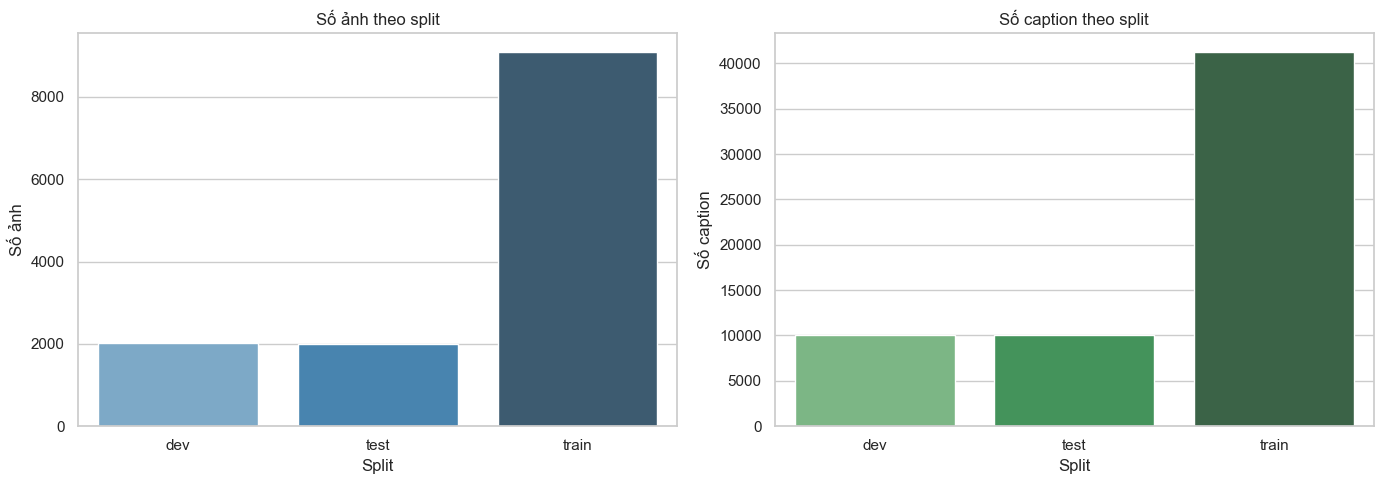

C:\Users\nviquang\AppData\Local\Temp\ipykernel_8556\639823513.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_stats, x='split', y='avg_captions_per_image', palette='Oranges_d')


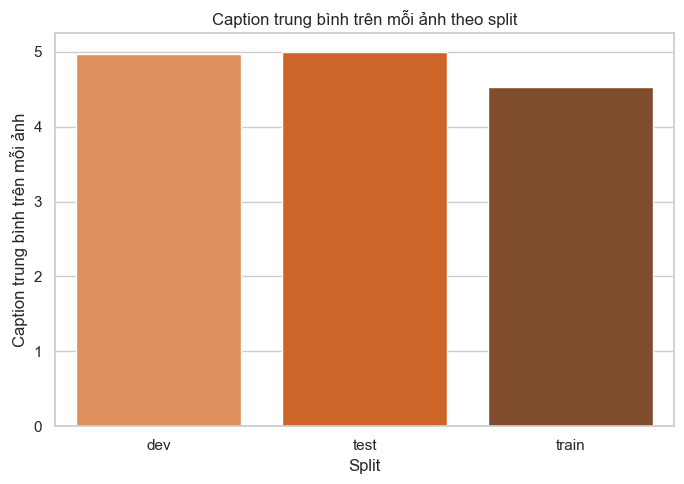

In [22]:
overall_stats = pd.DataFrame([
    {
        'scope': 'all',
        'unique_images': dataset_df['image_file'].nunique(),
        'total_captions': len(dataset_df)
    }
])

split_stats = dataset_df.groupby('split').agg(
    unique_images=('image_file', 'nunique'),
    total_captions=('caption', 'size')
).reset_index()
split_stats['avg_captions_per_image'] = split_stats['total_captions'] / split_stats['unique_images']

display(overall_stats)
display(split_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=split_stats, x='split', y='unique_images', ax=axes[0], palette='Blues_d')
axes[0].set_title('Số ảnh theo split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Số ảnh')

sns.barplot(data=split_stats, x='split', y='total_captions', ax=axes[1], palette='Greens_d')
axes[1].set_title('Số caption theo split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Số caption')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(data=split_stats, x='split', y='avg_captions_per_image', palette='Oranges_d')
plt.title('Caption trung bình trên mỗi ảnh theo split')
plt.xlabel('Split')
plt.ylabel('Caption trung bình trên mỗi ảnh')
plt.tight_layout()
plt.show()

## Kiểm tra chất lượng

Phần này kiểm tra các vấn đề phổ biến trong caption và annotation để phục vụ mô tả chất lượng dữ liệu trong báo cáo.

In [23]:
dataset_df['caption_is_null'] = dataset_df['caption'].isna()
dataset_df['caption_is_empty'] = dataset_df['caption'].fillna('').str.strip().eq('')
dataset_df['caption_is_nearly_empty'] = dataset_df['caption'].fillna('').map(lambda value: len(value.split()) <= 1)
dataset_df['caption_too_short'] = dataset_df['caption_word_count'] < 3
dataset_df['caption_too_long'] = dataset_df['caption_word_count'] > 40
dataset_df['caption_has_unusual_chars'] = dataset_df['caption'].fillna('').str.contains(r"[^\w\s,.;:!?%\-/\'\"\(\)]", regex=True)
dataset_df['caption_is_global_duplicate'] = dataset_df.duplicated(subset=['caption'], keep=False) & dataset_df['caption'].notna() & ~dataset_df['caption_is_empty']
dataset_df['caption_is_duplicate_in_same_image'] = dataset_df.duplicated(subset=['image_file', 'caption'], keep=False) & dataset_df['caption'].notna() & ~dataset_df['caption_is_empty']

quality_summary = pd.DataFrame([
    {'issue_type': 'caption_null', 'count': int(dataset_df['caption_is_null'].sum())},
    {'issue_type': 'caption_empty', 'count': int(dataset_df['caption_is_empty'].sum())},
    {'issue_type': 'caption_nearly_empty', 'count': int(dataset_df['caption_is_nearly_empty'].sum())},
    {'issue_type': 'caption_global_duplicate', 'count': int(dataset_df['caption_is_global_duplicate'].sum())},
    {'issue_type': 'caption_duplicate_in_same_image', 'count': int(dataset_df['caption_is_duplicate_in_same_image'].sum())},
    {'issue_type': 'caption_too_short', 'count': int(dataset_df['caption_too_short'].sum())},
    {'issue_type': 'caption_too_long', 'count': int(dataset_df['caption_too_long'].sum())},
    {'issue_type': 'caption_unusual_chars', 'count': int(dataset_df['caption_has_unusual_chars'].sum())}
])

display(quality_summary)

issue_samples = {
    'caption_null': dataset_df.loc[dataset_df['caption_is_null'], ['split', 'image_file', 'caption_original', 'caption']].head(10),
    'caption_empty': dataset_df.loc[dataset_df['caption_is_empty'], ['split', 'image_file', 'caption_original', 'caption']].head(10),
    'caption_nearly_empty': dataset_df.loc[dataset_df['caption_is_nearly_empty'], ['split', 'image_file', 'caption_original', 'caption']].head(10),
    'caption_global_duplicate': dataset_df.loc[dataset_df['caption_is_global_duplicate'], ['split', 'image_file', 'caption_original', 'caption']].head(10),
    'caption_duplicate_in_same_image': dataset_df.loc[dataset_df['caption_is_duplicate_in_same_image'], ['split', 'image_file', 'caption_original', 'caption']].head(10),
    'caption_too_short': dataset_df.loc[dataset_df['caption_too_short'], ['split', 'image_file', 'caption_original', 'caption', 'caption_word_count']].head(10),
    'caption_too_long': dataset_df.loc[dataset_df['caption_too_long'], ['split', 'image_file', 'caption_original', 'caption', 'caption_word_count']].head(10),
    'caption_unusual_chars': dataset_df.loc[dataset_df['caption_has_unusual_chars'], ['split', 'image_file', 'caption_original', 'caption']].head(10)
}

for issue_name, sample_df in issue_samples.items():
    display(Markdown('### ' + issue_name))
    display(sample_df)

,issue_type,count
0,caption_null,0
1,caption_empty,2
2,caption_nearly_empty,4
3,caption_global_duplicate,369
4,caption_duplicate_in_same_image,10
5,caption_too_short,4
6,caption_too_long,493
7,caption_unusual_chars,0


### caption_null

,split,image_file,caption_original,caption


### caption_empty

,split,image_file,caption_original,caption
21576,train,00000004150.jpg,,
26913,train,00000010901.jpg,,


...

,split,image_file,caption_original,caption,caption_word_count
19666,train,00000000801.jpg,phái,phái,1
21576,train,00000004150.jpg,,,0
26913,train,00000010901.jpg,,,0
34479,train,00000006761.jpg,những,những,1


### caption_too_long

,split,image_file,caption_original,caption,caption_word_count
6110,train,00000000900.jpg,một đội sư rồng gồm năm người mặc áo màu cam đang biểu diễn trước cổng siêu thị với bên phải là một nhóm người mặc áo đỏ tay cầm bong bóng có nhiều màu sắc ...,một đội sư rồng gồm năm người mặc áo màu cam đang biểu diễn trước cổng siêu thị với bên phải là một nhóm người mặc áo đỏ tay cầm bong bóng có nhiều màu sắc ...,44
6459,train,00000000958.jpg,gồm hai bức hình bức thức nhất là một người phụ nữ áo xanh mũ vàng đang đạp xe đạp trên đường cạnh một cây hoa màu tím hình ảnh thứ hai là một ngôi nhà cổ d...,gồm hai bức hình bức thức nhất là một người phụ nữ áo xanh mũ vàng đang đạp xe đạp trên đường cạnh một cây hoa màu tím hình ảnh thứ hai là một ngôi nhà cổ d...,45
6460,train,00000000958.jpg,có 2 bức ảnh bức thứ 1 là ảnh 1 người chạy xe đạp đi ngang qua tán cây tán cây có những bông hoa màu tím bức thứ 2 là ảnh 1 tòa nhà cũ có 3 cửa sổ đang mở,có 2 bức ảnh bức thứ 1 là ảnh 1 người chạy xe đạp đi ngang qua tán cây tán cây có những bông hoa màu tím bức thứ 2 là ảnh 1 tòa nhà cũ có 3 cửa sổ đang mở,42
7170,train,00000001978.jpg,biển hiệu màu đỏ có hình quả táo có dòng chữ màu trắng ở giữa biển hiệu phía bên dưới biển hiệu màu đỏ là quầy hàng để trái cây có 2 người phụ nữ đang đứn...,biển hiệu màu đỏ có hình quả táo có dòng chữ màu trắng ở giữa biển hiệu phía bên dưới biển hiệu màu đỏ là quầy hàng để trái cây có 2 người phụ nữ đang đứng ...,47
7343,train,00000003107.jpg,bé gái mặc áo hồng quần nâu đang đẩy 2 xe đẩy đồ chơi bên trong 2 xe đẩy có chứa nhiều món đồ chơi nhỏ chiếc xe đẩy màu hồng có bánh xe màu xanh lá chiếc x...,bé gái mặc áo hồng quần nâu đang đẩy 2 xe đẩy đồ chơi bên trong 2 xe đẩy có chứa nhiều món đồ chơi nhỏ chiếc xe đẩy màu hồng có bánh xe màu xanh lá chiếc xe...,48
7439,train,00000003123.jpg,ảnh có màu trắng đen có 2 người phụ nữ đang đứng trước sạp bán đồ người phụ nữ cầm túi xách để trên vai đang đứng nhìn phía trước người phụ nữ áo trắng ngồ...,ảnh có màu trắng đen có 2 người phụ nữ đang đứng trước sạp bán đồ người phụ nữ cầm túi xách để trên vai đang đứng nhìn phía trước người phụ nữ áo trắng ngồi...,46
7550,train,00000003142.jpg,có hàng rào chắn ngang người đàn ông và người phụ nữ trên hàng rào có nhiều bảng thông báo người phụ nữ đứng bên trong đang ký giấy phía dưới chân có nhiều ...,có hàng rào chắn ngang người đàn ông và người phụ nữ trên hàng rào có nhiều bảng thông báo người phụ nữ đứng bên trong đang ký giấy phía dưới chân có nhiều ...,42
8390,train,00000003285.jpg,một nam thanh niên mặc áo sơ mi trắng đội nón đang đi bên cạnh một cô gái mặc áo dài trắng đang gánh một đòn gánh chứa đầy hoa phượng đỏ trên mọt con đường ...,một nam thanh niên mặc áo sơ mi trắng đội nón đang đi bên cạnh một cô gái mặc áo dài trắng đang gánh một đòn gánh chứa đầy hoa phượng đỏ trên mọt con đường ...,45
8414,train,00000003289.jpg,một nam thanh niên mặc áo trắng và một cô gái mặc váy trắng đang khoác tay nhau bên cạnh một người đàn ông mặc áo sơ mi xanh đội nón và một chiếc xe đạp đan...,một nam thanh niên mặc áo trắng và một cô gái mặc váy trắng đang khoác tay nhau bên cạnh một người đàn ông mặc áo sơ mi xanh đội nón và một chiếc xe đạp đan...,44
8726,train,00000004285.jpg,một cô gái mặc bộ trang phục có hoa màu đỏ đang ngồi tạo dáng bên chiếc xe đạp có giỏ đựng đầy hoa màu hồng ngay cạnh một dòng sông với các tòa nhà cao tầng...,một cô gái mặc bộ trang phục có hoa màu đỏ đang ngồi tạo dáng bên chiếc xe đạp có giỏ đựng đầy hoa màu hồng ngay cạnh một dòng sông với các tòa nhà cao tầng...,44


### caption_unusual_chars

,split,image_file,caption_original,caption


## Kiểm tra tính toàn vẹn ảnh

Mỗi ảnh được kiểm tra số tồn tại trong thư mục `data/images` và thử mở để phát hiện các file ảnh bị lỗi hoặc không được đọc.

In [24]:
unique_images_df = dataset_df[['image_file']].drop_duplicates().copy()
unique_images_df['image_path'] = unique_images_df['image_file'].map(lambda file_name: images_dir / file_name)
unique_images_df['image_exists'] = unique_images_df['image_path'].map(Path.exists)

image_status_rows = []
for row in unique_images_df.itertuples(index=False):
    image_file = row.image_file
    image_path = row.image_path
    exists = row.image_exists
    is_corrupt = False
    error_message = ''
    if exists:
        try:
            with Image.open(image_path) as image:
                image.verify()
        except (UnidentifiedImageError, OSError, ValueError) as error:
            is_corrupt = True
            error_message = str(error)
    image_status_rows.append({
        'image_file': image_file,
        'image_exists': exists,
        'image_is_corrupt': is_corrupt,
        'image_error': error_message
    })

image_status_df = pd.DataFrame(image_status_rows)
image_integrity_summary = pd.DataFrame([
    {'metric': 'images_in_annotations', 'value': int(len(image_status_df))},
    {'metric': 'images_exist', 'value': int(image_status_df['image_exists'].sum())},
    {'metric': 'images_missing', 'value': int((~image_status_df['image_exists']).sum())},
    {'metric': 'images_corrupt', 'value': int(image_status_df['image_is_corrupt'].sum())}
])

display(image_integrity_summary)
display(image_status_df.loc[(~image_status_df['image_exists']) | (image_status_df['image_is_corrupt'])].head(20))

,metric,value
0,images_in_annotations,13100
1,images_exist,13100
2,images_missing,0
3,images_corrupt,0


,image_file,image_exists,image_is_corrupt,image_error


## Phân tích độ dài caption

Độ dài caption được tính theo số từ sau chuẩn hóa để mô tả mức độ ngắn dài của câu mô tả trong toàn bộ dataset và từng split.

,scope,mean,median,min,max,std
0,all,17.609298,16.0,0.0,127.0,6.265374


,split,mean,median,min,max,std
0,dev,18.645071,17.0,3,83,6.902176
1,test,17.857814,17.0,6,50,5.043905
2,train,17.297808,16.0,0,127,6.340416


C:\Users\nviquang\AppData\Local\Temp\ipykernel_8556\442587572.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_df, x='split', y='caption_word_count', ax=axes[1], palette='Set2')


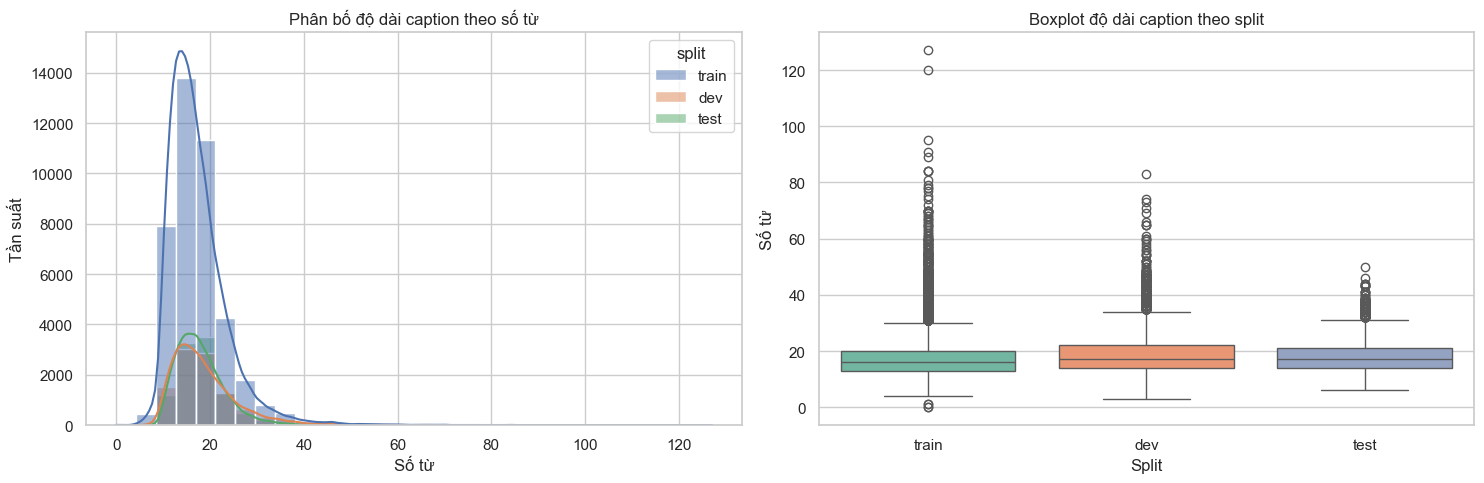

,split,image_file,caption,caption_word_count
37898,train,00000004489.jpg,ở góc bên trái phía trên có một người mặc áo xanh lá trước một kệ hàng của dãy hàng trên một lối đi và một dãy hàng khác cạnh lối đi có nhiều áo quần được t...,127
37765,train,00000004462.jpg,ở góc trên phía trái có một người áo xanh đang di chuyển dưới một lối đi có mái che và ở xong có nhiều người khác và ở dưới có một người mang áo trắng đang ...,120
38169,train,00000004844.jpg,con đường có người đang đội nón và người đang đi trên xe hai bánh và hai người khác đang di chuyển trên đường và ở bên trái có dãy nhà có tường màu trắng và...,95
37923,train,00000004494.jpg,một người đang đứng trước một ngôi nhà ba tầng có màu vàng và một bảng tên đường bên trái cổng ra vào và một cột điện ở bên phải cổng ra vào ở trên có bảng ...,91
38134,train,00000004837.jpg,một người đang đứng trước một cửa hiệu có hai tầng có một tấm biển được đặt trước cửa và cạnh bên có hai chiếc xe máy và có một gốc cây xanh ở bên phải ngườ...,89
38040,train,00000004818.jpg,nhiều người đang di chuyển trên xe máy trên con đường và ở sau có lối đi có một cổng có hai tầng và có một lá cờ được treo trên và ở bên trái có một bảng tê...,84
37168,train,00000003640.jpg,một cửa hiệu được đặt trước con đường có tán cây có lá đỏ ở góc trái và có một chiếc xe máy đậu và hai ghế trắng và một bảng quảng cáo đậu trước hai cửa ra ...,84
37428,train,00000003693.jpg,hai người phụ nữ đang đội nón gánh hàng ở trên con đường và bên trái con đường có dãy nhà có hai tầng và có cửa sổ và cửa ra vào và có một người đội nón trắ...,84
42063,dev,00000001265.jpg,một số bảo tàng đều treo lá cờ đổ sao vàng bên trái trên cùng là một bảo tàng màu vàng đậm bên phải trên cùng là bảo tàng vàng nhạt có nhiều cây xanh ở giữa...,83
38075,train,00000004825.jpg,một khu chợ có các chùm dây màu xanh ở trên và ở dưới có nhiều gian hàng có mái che với nhiều màu khác nhau như xanh lá cây và vàng và đen và trắng và đỏ và...,81


In [25]:
caption_length_overall = dataset_df['caption_word_count'].agg(['mean', 'median', 'min', 'max', 'std']).rename('all').to_frame().T.reset_index(names='scope')
caption_length_by_split = dataset_df.groupby('split')['caption_word_count'].agg(['mean', 'median', 'min', 'max', 'std']).reset_index()

display(caption_length_overall)
display(caption_length_by_split)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=dataset_df, x='caption_word_count', hue='split', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Phân bố độ dài caption theo số từ')
axes[0].set_xlabel('Số từ')
axes[0].set_ylabel('Tần suất')

sns.boxplot(data=dataset_df, x='split', y='caption_word_count', ax=axes[1], palette='Set2')
axes[1].set_title('Boxplot độ dài caption theo split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Số từ')
plt.tight_layout()
plt.show()

long_caption_examples = dataset_df.sort_values('caption_word_count', ascending=False)[['split', 'image_file', 'caption', 'caption_word_count']].head(15)
display(long_caption_examples)


## Phân tích từ vựng cơ bản

Việc tách từ ở mức độ đơn giản được dùng để tạo các thống kê mô tả dễ diễn giải, không nhằm thay thế các bước tiền xử lý NLP chuyên sâu.

,metric,value
0,total_tokens_after_basic_filter,880663
1,unique_tokens_after_basic_filter,4123


,token,frequency
0,có,39889
1,màu,37268
2,người,28702
3,nhiều,24789
4,và,21885
5,hàng,15472
6,bên,14346
7,xanh,12907
8,trắng,12809
9,áo,12209


C:\Users\nviquang\AppData\Local\Temp\ipykernel_8556\2300313883.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tokens_df, x='frequency', y='token', palette='mako')


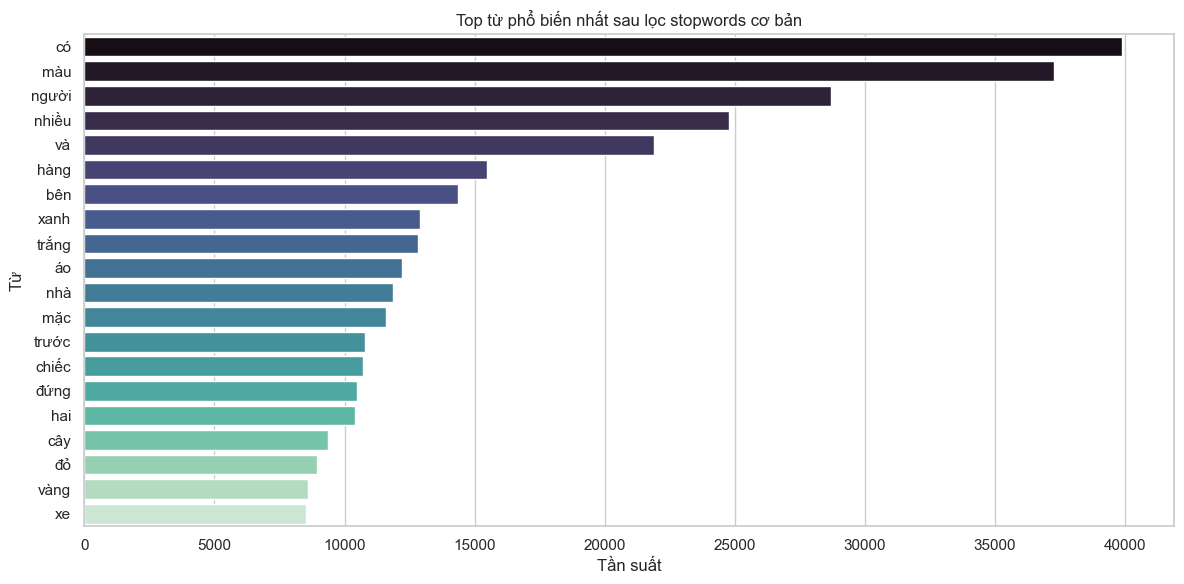

In [26]:
vietnamese_stopwords = {
    'về', 'là', 'của', 'cái', 'một', 'những', 'các', 'đang', 'trên', 'trong', 'ở', 'với', 'cho', 'được', 'bị', 'này', 'kia', 'đó', 'thì', 'ra', 'vào', 'từ', 'theo', 'rất'
}

def simple_tokenize(text):
    if pd.isna(text):
        return []
    return re.findall(r'\b\w+\b', str(text).lower(), flags=re.UNICODE)

all_tokens = [token for caption in dataset_df['caption'].dropna() for token in simple_tokenize(caption)]
content_tokens = [token for token in all_tokens if token not in vietnamese_stopwords]

token_counter = Counter(content_tokens)
top_tokens_df = pd.DataFrame(token_counter.most_common(20), columns=['token', 'frequency'])
vocab_summary = pd.DataFrame([
    {'metric': 'total_tokens_after_basic_filter', 'value': len(content_tokens)},
    {'metric': 'unique_tokens_after_basic_filter', 'value': len(set(content_tokens))}
])

display(vocab_summary)
display(top_tokens_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_tokens_df, x='frequency', y='token', palette='mako')
plt.title('Top từ phổ biến nhất sau lọc stopwords cơ bản')
plt.xlabel('Tần suất')
plt.ylabel('Từ')
plt.tight_layout()
plt.show()


## Kiểm tra rò rỉ dữ liệu giữa các split

Phần này kiểm tra số giao nhau giữa các split theo hai mức: trùng ảnh và trùng caption tuyệt đối sau chuẩn hóa.

In [27]:
split_names = ['train', 'dev', 'test']
pair_results = []
pair_examples = {}

for i, left_split in enumerate(split_names):
    for right_split in split_names[i + 1:]:
        left_df = dataset_df.loc[dataset_df['split'] == left_split]
        right_df = dataset_df.loc[dataset_df['split'] == right_split]
        shared_images = sorted(set(left_df['image_file']).intersection(set(right_df['image_file'])))
        shared_captions = sorted(set(left_df['caption'].dropna()).intersection(set(right_df['caption'].dropna())))
        pair_name = f'{left_split}-{right_split}'
        pair_results.append({
            'pair': pair_name,
            'shared_images': len(shared_images),
            'shared_captions': len(shared_captions)
        })
        pair_examples[pair_name] = {
            'images': pd.DataFrame({'image_file': shared_images[:10]}),
            'captions': pd.DataFrame({'caption': shared_captions[:10]})
        }

leakage_summary = pd.DataFrame(pair_results)
display(leakage_summary)

for pair_name, example_bundle in pair_examples.items():
    display(Markdown('### ' + pair_name))
    print('Shared image examples')
    display(example_bundle['images'])
    print('Shared caption examples')
    display(example_bundle['captions'])

,pair,shared_images,shared_captions
0,train-dev,0,3
1,train-test,0,1
2,dev-test,0,16


### train-dev

Shared image examples


,image_file


Shared caption examples


...

### dev-test

Shared image examples


,image_file


Shared caption examples


,caption
0,một cửa hàng có bảng hiệu màu xanh với những dòng chữ và hình ảnh mang màu sắc khác nhau
1,một cửa hàng có bảng hiệu màu đen với những dòng chữ có màu sắc khác nhau
2,một dãy những ngôi nhà màu vàng với mái ngói màu nâu
3,một tòa thành cổ màu vàng với những bức tường màu nâu
4,một tờ giấy màu trắng có chữ màu đen mang thông tin quảng cáo
5,nhiều người đang đi lại giữa những gian hàng khác nhau
6,trên một con phố có rất nhiều người đang đi lại
7,tại một cửa hàng có rất nhiều hàng hóa đang được bày bán
8,tại một cửa hàng có rất nhiều người đang ngồi ăn uống
9,tại một khu chợ có nhiều người đang làm việc


## Làm sạch dữ liệu

Dataset cleaned chỉ loại bỏ các trường hợp ảnh không tồn tại, ảnh hư và caption null hoặc rỗng, nhằm giữ lại tối đa dữ liệu hợp lệ cho bước huấn luyện.

In [28]:
dataset_with_images_df = dataset_df.merge(image_status_df, on='image_file', how='left')
cleaned_df = dataset_with_images_df.loc[
    dataset_with_images_df['caption'].notna()
    & ~dataset_with_images_df['caption_is_empty']
    & dataset_with_images_df['image_exists'].fillna(False)
    & ~dataset_with_images_df['image_is_corrupt'].fillna(False)
].copy()

cleaned_df = cleaned_df[['split', 'image_id', 'image_file', 'caption_original', 'caption', 'caption_word_count']].reset_index(drop=True)

cleaning_comparison = pd.DataFrame([
    {
        'stage': 'before_cleaning',
        'rows': len(dataset_df),
        'unique_images': dataset_df['image_file'].nunique()
    },
    {
        'stage': 'after_cleaning',
        'rows': len(cleaned_df),
        'unique_images': cleaned_df['image_file'].nunique()
    }
])

display(cleaning_comparison)
display(cleaned_df.head(10))

,stage,rows,unique_images
0,before_cleaning,61241,13100
1,after_cleaning,61239,13100


,split,image_id,image_file,caption_original,caption,caption_word_count
0,train,00000000782,00000000782.jpg,một con phố vắng vẻ có một tán cây lớn che ngang,một con phố vắng vẻ có một tán cây lớn che ngang,12
1,train,00000000782,00000000782.jpg,có một cái cây xanh trên vỉa hè phía bên phải của con đường nhựa,có một cái cây xanh trên vỉa hè phía bên phải của con đường nhựa,15
2,train,00000000782,00000000782.jpg,có một người đang chạy xe băng qua ngã tư đường,có một người đang chạy xe băng qua ngã tư đường,11
3,train,00000000782,00000000782.jpg,một người đang đi xe máy qua góc ngã tư có cây xanh nằm ở góc đường và các tòa nhà dọc theo các con đường,một người đang đi xe máy qua góc ngã tư có cây xanh nằm ở góc đường và các tòa nhà dọc theo các con đường,26
4,train,00000000782,00000000782.jpg,có một con đường đầy cây xanh và những dãy nhà,có một con đường đầy cây xanh và những dãy nhà,11
5,train,00000000783,00000000783.jpg,một ngôi đền cổ với 5 cửa vào được sơn màu xám xung quanh là nhiều cây xanh,một ngôi đền cổ với 5 cửa vào được sơn màu xám xung quanh là nhiều cây xanh,18
6,train,00000000783,00000000783.jpg,mỗi cánh cổng đều được dẫn lên bởi bốn bậc thang,mỗi cánh cổng đều được dẫn lên bởi bốn bậc thang,11
7,train,00000000783,00000000783.jpg,bên phải cánh cổng có biển hiệu chữ hán có một cây cột,bên phải cánh cổng có biển hiệu chữ hán có một cây cột,13
8,train,00000000783,00000000783.jpg,một cổng kiến trúc cổ có ba tầng và có hàng cây mọc phía bên trái cổng,một cổng kiến trúc cổ có ba tầng và có hàng cây mọc phía bên trái cổng,17
9,train,00000000783,00000000783.jpg,một ngôi nhà lớn màu nâu bên cạnh một cái cây xanh,một ngôi nhà lớn màu nâu bên cạnh một cái cây xanh,12


## Xuất dữ liệu

Các file đầu ra được lưu dưới dạng CSV và JSONL để tiện kiểm tra thủ công, đồng thời thuận tiện cho các bước tiền xử lý tiếp theo trước khi finetune.

In [29]:
output_dir = data_dir
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_paths = {
    'train': output_dir / 'processed_train.csv',
    'dev': output_dir / 'processed_dev.csv',
    'test': output_dir / 'processed_test.csv',
    'all_csv': output_dir / 'processed_all.csv'
}

output_jsonl_paths = {
    'train_jsonl': output_dir / 'processed_train.jsonl',
    'dev_jsonl': output_dir / 'processed_dev.jsonl',
    'test_jsonl': output_dir / 'processed_test.jsonl',
    'all_jsonl': output_dir / 'processed_all.jsonl'
}

export_columns = ['split', 'image_file', 'caption']

for split_name in ['train', 'dev', 'test']:
    split_export_df = cleaned_df.loc[cleaned_df['split'] == split_name, export_columns].reset_index(drop=True)
    split_export_df.to_csv(output_csv_paths[split_name], index=False, encoding='utf-8-sig')
    split_export_df.to_json(output_jsonl_paths[f'{split_name}_jsonl'], orient='records', lines=True, force_ascii=False)

cleaned_df[export_columns].to_csv(output_csv_paths['all_csv'], index=False, encoding='utf-8-sig')
cleaned_df[export_columns].to_json(output_jsonl_paths['all_jsonl'], orient='records', lines=True, force_ascii=False)

export_report = pd.DataFrame([
    {'name': name, 'path': str(path), 'exists': path.exists(), 'size_bytes': path.stat().st_size if path.exists() else 0}
    for name, path in {**output_csv_paths, **output_jsonl_paths}.items()
])
display(export_report)

,name,path,exists,size_bytes
0,train,c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\processed_train.csv,True,5118783
1,dev,c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\processed_dev.csv,True,1302051
2,test,c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\processed_test.csv,True,1265539
3,all_csv,c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\processed_all.csv,True,7686315
4,train_jsonl,c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\processed_train.jsonl,True,6685722
5,dev_jsonl,c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\processed_dev.jsonl,True,1682098
6,test_jsonl,c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\processed_test.jsonl,True,1645548
7,all_jsonl,c:\Users\nviquang\Documents\University\ThirdYear\Ky2\TTCS\Repo\SourceCode\data\processed_all.jsonl,True,10013368


## Kết luận

Cell cuối cùng tổng hợp các chỉ số chính dưới dạng văn bản ngắn gọn để có thể dùng làm cơ sở viết phần nhận xét dữ liệu trong báo cáo tuần.

In [30]:
total_images = int(dataset_df['image_file'].nunique())
total_captions = int(len(dataset_df))
avg_captions_per_image = total_captions / total_images if total_images else 0
empty_captions = int(dataset_df['caption_is_empty'].sum())
null_captions = int(dataset_df['caption_is_null'].sum())
duplicate_captions = int(dataset_df['caption_is_global_duplicate'].sum())
duplicate_same_image = int(dataset_df['caption_is_duplicate_in_same_image'].sum())
missing_images = int((~image_status_df['image_exists']).sum())
corrupt_images = int(image_status_df['image_is_corrupt'].sum())

if missing_images == 0 and corrupt_images == 0 and empty_captions == 0 and null_captions == 0:
    cleanliness_note = 'Dữ liệu nhân chung sạch, đầy đủ và có thể dùng trực tiếp cho bước huấn luyện sau khi chuẩn hóa caption.'
else:
    cleanliness_note = 'Dữ liệu còn một số vấn đề cần lưu ý, nhưng đã được làm sạch ở mức cơ bản để phục vụ huấn luyện.'

report_lines = [
    'TỔNG KẾT DỮ LIỆU UIT-OPENVIIC',
    f'- Tổng số ảnh: {total_images:,}',
    f'- Tổng số caption: {total_captions:,}',
    f'- Caption trung bình trên mỗi ảnh: {avg_captions_per_image:.2f}',
    f'- Caption null: {null_captions:,}',
    f'- Caption rỗng: {empty_captions:,}',
    f'- Caption trùng toàn cục: {duplicate_captions:,}',
    f'- Caption trùng trong cùng ảnh: {duplicate_same_image:,}',
    f'- Ảnh thiếu: {missing_images:,}',
    f'- Ảnh hư: {corrupt_images:,}',
    f'- Số dùng sau làm sạch: {len(cleaned_df):,}',
    f'- Nhận xét ngắn: {cleanliness_note}'
]

print('\n'.join(report_lines))


TỔNG KẾT DỮ LIỆU UIT-OPENVIIC
- Tổng số ảnh: 13,100
- Tổng số caption: 61,241
- Caption trung bình trên mỗi ảnh: 4.67
- Caption null: 0
- Caption rỗng: 2
- Caption trùng toàn cục: 369
- Caption trùng trong cùng ảnh: 10
- Ảnh thiếu: 0
- Ảnh hư: 0
- Số dùng sau làm sạch: 61,239
- Nhận xét ngắn: Dữ liệu còn một số vấn đề cần lưu ý, nhưng đã được làm sạch ở mức cơ bản để phục vụ huấn luyện.
